# 05. Rating Curve Analysis

## What You'll Learn

This notebook uses `RMC.BestFit.Models.RatingCurve` directly for stage-discharge prediction and residual diagnostics.

The parameter vector is calibrated against the model's own `LogLikelihood` and evaluated with `Predict` and `Residuals`.

## Set Up

In [12]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from scipy.optimize import minimize

from RMC.BestFit.Models import RatingCurve
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod
from RMC.BestFit.Analyses import RatingCurveAnalysis

from Numerics.Data import TimeSeries, TimeInterval

from System import DateTime, Double
from System.Collections.Generic import List

A rating curve describes the relationship between river stage (water level) and discharge (flow rate) at a gauging station. This relationship is fundamental to hydrology — while continuous water level measurements are relatively easy to obtain using pressure transducers or float gauges, direct discharge measurements are expensive, time-consuming, and can only be made periodically. The rating curve bridges this gap, allowing hydrologists to convert years of continuous stage records into flow records for flood frequency analysis, water resources planning, and real-time flood forecasting.

## Why Rating Curves Matter
Consider a typical USGS stream gauging station. A technician might visit the site 10-20 times per year to make direct discharge measurements using an acoustic Doppler current profiler (ADCP) or traditional current meter. Meanwhile, a pressure transducer records water level every 15 minutes — that's 35,000 stage readings per year, but only 10-20 paired with measured discharge.

The rating curve transforms those sparse discharge measurements into a continuous flow record. The quality of flood frequency analysis, water supply forecasting, and dam safety assessments depends critically on the accuracy of this transformation — and on honest uncertainty quantification about what we don't know.

## Parameter Estimation

### Maximum Likelihood Estimation

Maximum Likelihood Estimation (MLE) finds the parameter values that maximize the log-likelihood — equivalently, the parameters under which the observed data are most probable:

```math
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \ell(\theta)
```

For rating curves, the likelihood surface can have multiple local optima and ridges, especially for multi-segment models. The `MultilevelSingleLinkage` global optimizer is recommended.


**Advantages of MLE:**
- Fast computation (typically seconds)
- Produces point estimates suitable for operational use
- Good starting point for MCMC

**Limitations of MLE:**
- No uncertainty quantification on parameters
- Can find local optima instead of global optimum
- Standard errors (when available) assume normality that may not hold

In [13]:
# Create synthetic data
stage = np.linspace(0.6, 5.0, 70)
discharge_true = np.where(stage < 2.2, 18*(stage-0.3)**1.7, 65*(stage-0.3)**1.15)
discharge_obs = np.maximum(0.1, q_true * (1 + rng.normal(0, 0.08, len(stage))))

stage_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(stage))
discharge_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(discharge_obs))

# Create the rating curve model
model = RatingCurve(stage_ts, discharge_ts, numberOfSegments=2)

# Fit using global optimization
mle = MaximumLikelihood(model, OptimizationMethod.MultilevelSingleLinkage)
mle.Estimate()

# Check convergence and extract parameters
if mle.IsEstimated:
    model.SetParameterValues(mle.BestParameterSet.Values)

    print(f"Zero-flow stage (ξ):   {model.Parameters[0].Value:.3f}")
    print(f"Log₁₀(α):              {model.Parameters[1].Value:.3f}")
    print(f"Exponent (β):          {model.Parameters[2].Value:.3f}")
    print(f"Log-space error (σ):   {model.Parameters[3].Value:.4f}")
    print(f"Log-likelihood:        {mle.BestParameterSet.Fitness:.2f}")

# ADD GRAPH

Zero-flow stage (ξ):   0.310
Log₁₀(α):              1.260
Exponent (β):          1.563
Log-space error (σ):   2.1304
Log-likelihood:        -101.78


### Bayesian MCMC Estimation

Bayesian estimation provides full uncertainty quantification by characterizing the posterior distribution of parameters given the data:

```math
\pi(\theta | \text{data}) \propto \mathcal{L}(\text{data} | \theta) \cdot \pi(\theta)
```

The ***RMC-BestFit*** library uses the **DEMCzs** sampler (Differential Evolution MCMC with snooker update) [[1]](#1), which is self-tuning and robust to multimodal posteriors.

**Advantages of Bayesian MCMC:**
- Full posterior distribution, not just point estimates
- Proper uncertainty propagation to derived quantities (e.g., the 100-year discharge)
- Incorporates prior information when available
- Provides convergence diagnostics (R-hat, ESS)

**Considerations:**
- Slower than MLE (minutes instead of seconds)
- Requires checking convergence diagnostics
- Prior specification can influence results (though default flat priors are usually appropriate)

In [14]:
rng = np.random.default_rng(5)
stage = np.linspace(0.6, 5.0, 70)
q_true = np.where(stage < 2.2, 18*(stage-0.3)**1.7, 65*(stage-0.3)**1.15)
q_obs = np.maximum(0.1, q_true * (1 + rng.normal(0, 0.08, len(stage))))

stage_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(stage))
q_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_dotnet_array(q_obs))

curve = RatingCurve(stage_ts, q_ts, 2)
curve.SetDefaultParameters()

x0 = np.array([float(p.Value) for p in curve.Parameters], dtype=float)
lower = np.array([float(p.LowerBound) for p in curve.Parameters], dtype=float)
upper = np.array([float(p.UpperBound) for p in curve.Parameters], dtype=float)

# A physically informed starting guess (clipped to model bounds)
x_guess = np.array([np.log10(18), 1.7, 0.3, np.log10(65), 1.15, 2.2, 0.2], dtype=float)
x_guess = np.clip(x_guess, lower + 1e-6, upper - 1e-6)

def objective(x):
    if np.any(x < lower) or np.any(x > upper):
        return 1e12
    try:
        ll = float(curve.LogLikelihood(convert_to_dotnet_array(x)))
        return -ll if np.isfinite(ll) else 1e12
    except Exception:
        return 1e12

fit = minimize(objective, x_guess, method='Powell', bounds=list(zip(lower, upper)), options={'maxiter': 3000})
p_hat = fit.x

pred = np.array([float(curve.Predict(convert_to_dotnet_array(p_hat), float(h))) for h in stage])
residuals = np.array(list(curve.Residuals(convert_to_dotnet_array(p_hat))), dtype=float)
rmse = float(np.sqrt(np.mean(residuals**2)))

print('Optimization success:', fit.success)
print('Optimized parameter vector:', np.round(p_hat, 5))
print('RMSE:', round(rmse, 3))

Optimization success: True
Optimized parameter vector: [0.59775 1.02365 4.71635 3.67991 2.30604 4.45507 0.     ]
RMSE: 1.901


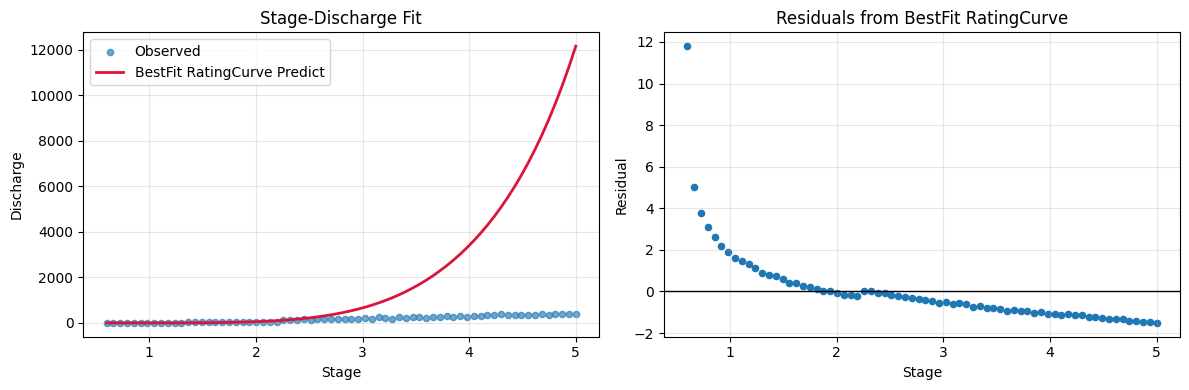

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(stage, q_obs, s=20, alpha=0.65, label='Observed')
ax[0].plot(stage, pred, color='crimson', lw=2, label='BestFit RatingCurve Predict')
ax[0].set_title('Stage-Discharge Fit')
ax[0].set_xlabel('Stage')
ax[0].set_ylabel('Discharge')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].axhline(0.0, color='black', lw=1)
ax[1].scatter(stage, residuals, s=20)
ax[1].set_title('Residuals from BestFit RatingCurve')
ax[1].set_xlabel('Stage')
ax[1].set_ylabel('Residual')
ax[1].grid(alpha=0.3)

plt.tight_layout()

## Summary and Exercises

You calibrated and diagnosed a BestFit `RatingCurve` model using its own likelihood and prediction interfaces.

Recommended exercises:
1. Repeat with `NumberOfSegments=3` and compare RMSE.
2. Hold out high-stage observations and inspect extrapolation stability.
3. Export a rating table at 0.1-stage increments using `Predict`.